In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import natsort
import re

### Set 123 Bus Origin Data Folder

In [2]:
origin_path_str = "Data_public_5year"
origin_path = Path(origin_path_str)

### Set Target Model Input Folder

In [3]:
target_path_str = "data_123_bus_kay"
target_path = Path(target_path_str)

## Process Bus Information

### Load from origin path and populate target dataframe

In [4]:
bus_data_path = origin_path / "Bus_data.csv"
bus_data_origin = pd.read_csv(bus_data_path)
bus_data_target = pd.DataFrame(columns=["Bus ID", "Bus Name", "BaseKV", "Bus Type", "MW Load", "MVAR Load", "V Mag", "V Angle", "Area", "Zone", "Bus Lat", "Bus Long"])
bus_data_target["Bus ID"] = bus_data_origin["Bus Number"]
bus_data_target["Bus Name"] = bus_data_origin["Bus Name"]
bus_data_target["BaseKV"] = bus_data_origin["Nominal Voltage (KV)"]
bus_data_target["Zone"] = bus_data_origin["Weather Zone"]
bus_data_target["Bus Lat"] = bus_data_origin["Bus latitude"]
bus_data_target["Bus Long"] = bus_data_origin["Bus longitude"]
# the MW load will decide the load at each bus. 
bus_data_target["MW Load"] = bus_data_target["MW Load"].fillna(1)
# placeholder for 'PV' classes
bus_data_target["Bus Type"] = bus_data_target["Bus Type"].fillna("PV")
bus_data_target["MVAR Load"] = bus_data_target["MVAR Load"].fillna(0)
bus_data_target["Area"] = bus_data_origin["Bus Number"]
bus_data_target["V Mag"] = bus_data_target["V Mag"].fillna(1)
bus_data_target["V Angle"] = bus_data_target["V Angle"].fillna(0)

/var/folders/p0/8_mj7nxn1td_x1r_61m5pqh40000gn/T/ipykernel_4295/2884423847.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bus_data_target["MW Load"] = bus_data_target["MW Load"].fillna(1)
/var/folders/p0/8_mj7nxn1td_x1r_61m5pqh40000gn/T/ipykernel_4295/2884423847.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bus_data_target["MVAR Load"] = bus_data_target["MVAR Load"].fillna(0)
/var/folders/p0/8_mj7nxn1td_x1r_61m5pqh40000gn/T/ipykernel_4295/2884423847.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecate

### Write to CSV

In [5]:
bus_data_target.to_csv(target_path / "bus.csv",index=False)

## Process Branch Information

### Load from origin path and populate target dataframe

In [6]:
branch_origin_path = origin_path / "Line_data.csv"
branch_data_origin = pd.read_csv(branch_origin_path)
branch_data_target = pd.DataFrame(columns=["UID", "From Bus", "To Bus", "R", "X", "B", "Cont Rating", "LTE Rating", "STE Rating", "TR Ratio"])
branch_data_target["UID"] = branch_data_origin["line_num"]
branch_data_target["From Bus"] = branch_data_origin["From Bus Number"]
branch_data_target["To Bus"] = branch_data_origin["To Bus Number"]
branch_data_target["R"] = branch_data_origin["R, pu"]
branch_data_target["X"] = branch_data_origin["X, pu"]
branch_data_target["B"] = branch_data_origin["B, pu"]
branch_data_target["Cont Rating"] = branch_data_origin["Capacity (MW)"]
branch_data_target["LTE Rating"] = branch_data_origin["Capacity (MW)"]
branch_data_target["STE Rating"] = branch_data_origin["Capacity (MW)"]
branch_data_target["TR Ratio"] = branch_data_target["TR Ratio"].fillna(0)


/var/folders/p0/8_mj7nxn1td_x1r_61m5pqh40000gn/T/ipykernel_4295/223501519.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  branch_data_target["TR Ratio"] = branch_data_target["TR Ratio"].fillna(0)


### Write to CSV

In [7]:
branch_data_target.to_csv(target_path / "branch.csv", index=False)

## Process Fixed, Existing Gen Information (i.e., no timeseries, no candidate gens)

### Load from origin path and populate target dataframe

In [8]:
gen_origin_path = origin_path / "Generator_data.xlsx"
gen_data_origin= pd.read_excel(gen_origin_path, sheet_name="Gen data")
target_columns = ["GEN UID","Bus ID","Unit Type","Fuel","MW Inj","MVAR Inj","V Setpoint p.u.","PMax MW","PMin MW","QMax MVAR","QMin MVAR","Min Down Time Hr","Min Up Time Hr","Ramp Rate MW/Min","Start Time Cold Hr","Start Time Warm Hr","Start Time Hot Hr","Start Heat Cold MBTU","Start Heat Warm MBTU","Start Heat Hot MBTU","Non Fuel Start Cost $","Fuel Price $/MMBTU","Output_pct_0","Output_pct_1","Output_pct_2","Output_pct_3","Output_pct_4","HR_avg_0","HR_incr_1","HR_incr_2","HR_incr_3","HR_incr_4"]
unit_types_map = {"Nuclear":"NUC", "Natural Gas": "CT", "Coal": "COAL", "Wind": "WIND", "Solar": "PV", "Hydro": "HYDRO"}
fuel_types_map = {"NUC": "N", "COAL": "C", "CT": "G", "WIND": "W", "HYDRO": "H", "PV": "S"}
# this is changed to ref 24
up_time_map = {
    "G": 2,
    "W": 0,
    "C": 12,
    "H": 0,
    "N": 48,
    "S": 0,
}
down_time_map = {
    "G": 1,
    "W": 0,
    "C": 12,
    "H": 0,
    "S": 0,
    "N": 48,
}
# add the map of fuel price $/MMBTYYU
fuel_price_map = {
    "G": 2.29,
    "W": 0.00001, # avoid divided by 0
    "C": 1.78,
    "H": 0.00001,
    "N": 0.81035, # paper gives 17.44 $/MWh, here I use RTS-GMLC. Need to check how Prescient and Egret treat the nuclear generator.
    "S": 0.00001,
}
gen_data_target = pd.DataFrame(columns=target_columns)
gen_data_target["GEN UID"] = gen_data_origin["Gen Number"]
gen_data_target["Bus ID"] = gen_data_origin["Bus Number"]
gen_data_target["Unit Type"] = gen_data_origin["Fuel type"].map(unit_types_map)
gen_data_target["Fuel"] = gen_data_target["Unit Type"].map(fuel_types_map)
gen_data_target["PMax MW"] = gen_data_origin["Pmax (MW)"]
gen_data_target["PMin MW"] = gen_data_origin["Pmin (MW)"]
gen_data_target["QMax MVAR"] = gen_data_origin["Qmax (MVar)"]
gen_data_target["QMin MVAR"] = gen_data_origin["Qmin (MVar)"]
gen_data_target["Ramp Rate MW/Min"] = gen_data_origin["Ramping Rate(MW/min)"]
gen_data_target["Fuel Price $/MMBTU"] = gen_data_target["Fuel"].map(fuel_price_map)
# need to be fixed.
# the c0, c1, c2 and csu and not used in rts-gmlc, but I need to use them to calculate the Hr_avg and Hr_incr
gen_data_target["C0"] = gen_data_origin["C0($/MWh)"]
gen_data_target["C1"] = gen_data_origin["C1($/MWh)"]
gen_data_target["C2"] = 0.0016
gen_data_target["Csu"] = gen_data_origin["Csu($)"]

gen_data_target["V Setpoint p.u."].fillna(1, inplace=True)
gen_data_target["Min Up Time Hr"] = gen_data_target["Fuel"].map(up_time_map)
gen_data_target["Min Down Time Hr"] = gen_data_target["Fuel"].map(down_time_map)
# the following lines are arbitrary
# Assume all the generator is operated at pmin = 0.4, 0.6, 0.8, 1.0 * pmax
gen_data_target["Output_pct_0"] = gen_data_target["PMin MW"] / gen_data_target["PMax MW"]
gen_data_target["Output_pct_3"].fillna(1.0,inplace=True)
gen_data_target["Output_pct_1"] = (gen_data_target["Output_pct_3"] - gen_data_target["Output_pct_0"]) * 1 / 3 + gen_data_target["Output_pct_0"] 
gen_data_target["Output_pct_2"] = (gen_data_target["Output_pct_3"] - gen_data_target["Output_pct_0"]) * 2 / 3 + gen_data_target["Output_pct_0"]
gen_data_target.fillna("", inplace=True)

/var/folders/p0/8_mj7nxn1td_x1r_61m5pqh40000gn/T/ipykernel_4295/2291095247.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  gen_data_target["V Setpoint p.u."].fillna(1, inplace=True)
/var/folders/p0/8_mj7nxn1td_x1r_61m5pqh40000gn/T/ipykernel_4295/2291095247.py:50: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

In [27]:
"""
Drop-in C2 back-calculation for TX-123BT generators.
Add this function and the assignment line to your existing code,
replacing: gen_data_target["C2"] = 0.0016
"""

def calculate_c2(gen_data_target):
    """
    Back-calculate C2 (quadratic cost coefficient) for each generator
    using literature-based I/O curve coefficients scaled by unit size.
    
    Cost model: c_g = C0 + C1*P + C2*P^2  ($/hr)
    
    From the I/O curve H(P) = a + b*P + c*P^2 (MMBtu/hr):
        C2 = CF * c
    
    where 'c' is the quadratic I/O coefficient from Wood & Wollenberg [1],
    scaled as c = c_ref * (Pmax_ref / Pmax) to account for the fact that
    larger units have flatter efficiency curves.
    
    [1] Wood, Wollenberg, Sheblé, "Power Generation, Operation, and 
        Control," 3rd ed., Wiley, 2014.
    """
    # Reference I/O quadratic coefficients and unit sizes from [1]
    c_io_ref = {
        "C": {"c": 0.00142, "pref": 600.0},   # Coal steam
        "G": {"c": 0.00194, "pref": 400.0},   # Natural gas
        "N": {"c": 0.00005, "pref": 2400.0},  # Nuclear
        "W": {"c": 0.0, "pref": 1.0},
        "S": {"c": 0.0, "pref": 1.0},
        "H": {"c": 0.0, "pref": 1.0},
    }
    
    c2_values = []
    for _, row in gen_data_target.iterrows():
        fuel = row["Fuel"]
        pmax = row["PMax MW"]
        cf = row["Fuel Price $/MMBTU"]
        c1 = row["C1"]
        
        if fuel in ["W", "S", "H"] or pmax <= 0 or cf <= 0.001:
            c2_values.append(0.0)
            continue
        
        ref = c_io_ref.get(fuel, {"c": 0.00194, "pref": 400.0})
        scale = min(ref["pref"] / max(pmax, 10.0), 5.0)
        c2 = cf * ref["c"] * scale
        
        # Cap: quadratic term at Pmax stays < 20% of linear term
        if c1 > 0 and c2 * pmax > 0.20 * c1:
            c2 = 0.15 * c1 / pmax
        
        c2_values.append(round(c2, 6))
    
    return c2_values


# ============================================================
# USAGE: Replace your line:
#     gen_data_target["C2"] = 0.0016
# With:
#     gen_data_target["C2"] = calculate_c2(gen_data_target)
# ============================================================

In [43]:
gen_data_target["C2"] = calculate_c2(gen_data_target)
print(gen_data_target["C2"])
gen_data_target["C2"] = calculate_c2(gen_data_target)

0      0.000040
1      0.005834
2      0.007530
3      0.010074
4      0.004668
         ...   
287    0.000000
288    0.000000
289    0.000000
290    0.000000
291    0.000000
Name: C2, Length: 292, dtype: float64


In [49]:
## OR CHANGE C2
c2_map = {"G": 0.008, "C": 0.02, "N": 0.003, "W": 0, "H": 0, "S": 0}
gen_data_target["C2"] = gen_data_target["Fuel"].map(c2_map)

In [50]:
# Calculate HR_incr_1, HR_incr_2, HR_incr_3
# Assume all the generator is operated at pmin = 0.4, 0.6, 0.8, 1.0 * pmax

def _calculate_ercot_cost(p, c0, c1, c2):
    # eqation 1 in the paper
    # unit of p is MW
    cost = c0 + c1*p + c2*p**2
    
    return cost

def calculate_delta_incr_hr(p, c0, c1, c2, fp):
    # cost is the operation cost at each operation condition
    cost = []
    for i in p:
        cost.append(_calculate_ercot_cost(i, c0, c1, c2))

    # fuel_price * incr_h = delta_cost
    # the coal fuel price is 1.78$/MMBTU and natural gas fuel price is 2.29$/MMBTY
    delta_cost = np.diff(cost)
    delta_incr_hr = []
    for c in delta_cost:
        delta_incr_hr.append(c/fp)

    return delta_incr_hr


# calculate the HR_avg_0, which is related with the startup costs

def _calculate_ercot_startup_cost(Csu, pmax):
    # equation 2 in the paper, and the author simplified equation 2 to Csu * Pmax
    # Csu is Csu in the Generator_data.xlsx
    # Pmax is max capacity
    startup_cost = Csu * pmax
    
    return startup_cost

def calculate_H0_avg(Csu, pmax, fp):
    # H0_avg * fp  = startup cost
    startup_cost = _calculate_ercot_startup_cost(Csu, pmax)
    H0_avg = startup_cost / fp

    return H0_avg


for idx, row in gen_data_target.iterrows():
    ## change output_pct_0 to _3
    p = np.array([row["Output_pct_0"], row["Output_pct_1"], row["Output_pct_2"], row["Output_pct_3"]]) * row["PMax MW"]  # per unit of pmax
    # calculate HR_incr_1, HR_incr_2, HR_incr_3
    delta_incr_hr = calculate_delta_incr_hr(p, row["C0"], row["C1"], row["C2"], row["Fuel Price $/MMBTU"])
    gen_data_target.at[idx, 'HR_incr_1'] = delta_incr_hr[0]
    gen_data_target.at[idx, 'HR_incr_2'] = delta_incr_hr[1]
    gen_data_target.at[idx, 'HR_incr_3'] = delta_incr_hr[2]
    # calculate H0_avg
    H0_avg = calculate_H0_avg(gen_data_target.at[idx, "Csu"], row["PMax MW"], row["Fuel Price $/MMBTU"])
    gen_data_target.at[idx, 'HR_avg_0'] = H0_avg

# print(gen_data_target[["HR_incr_1","HR_incr_2","HR_incr_3","HR_avg_0"]].head(5))
# print(gen_data_target[["HR_incr_1","HR_incr_2","HR_incr_3","HR_avg_0"]].isna().sum())


In [51]:
startup_cols = [
    "Start Time Cold Hr",
    "Start Time Warm Hr",
    "Start Time Hot Hr",
    "Start Heat Cold MBTU",
    "Start Heat Warm MBTU",
    "Start Heat Hot MBTU",
    "Non Fuel Start Cost $"
]

gen_data_target[startup_cols] = 1

## plot fuel curve 

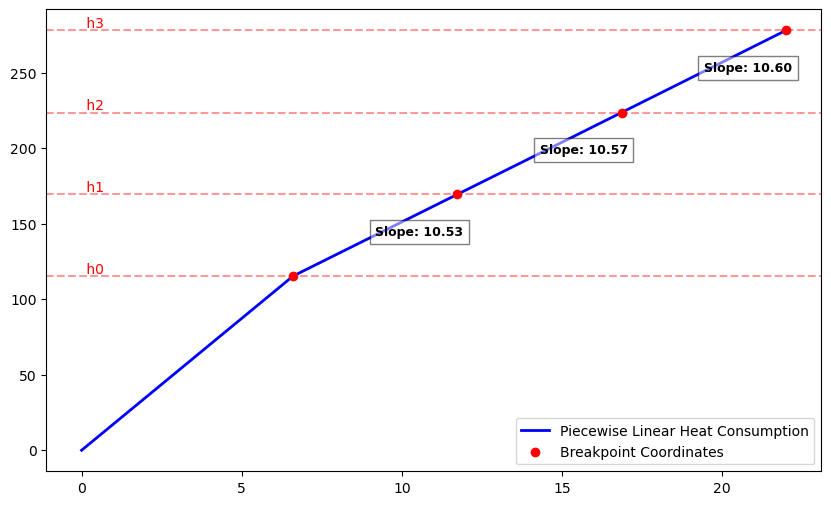

In [53]:
import numpy as np
import matplotlib.pyplot as plt

row = gen_data_target[gen_data_target['GEN UID'] == 14].iloc[0]

# X 轴坐标：实际功率点 (MW)
p = np.array([row["Output_pct_0"], row["Output_pct_1"], row["Output_pct_2"], row["Output_pct_3"]]) * row["PMax MW"]

# Y 轴坐标：累加的总热耗 (MMBTU)
# h0 是启动/空载热耗
h0 = row['HR_avg_0']
h1 = h0 + row['HR_incr_1']
h2 = h1 + row['HR_incr_2']
h3 = h2 + row['HR_incr_3']
h_points = [h0, h1, h2, h3]

# 2. 计算各段斜率 (Incremental Heat Rate)
slopes = []
for i in range(1, len(p)):
    slope = (h_points[i] - h_points[i-1]) / (p[i] - p[i-1])
    slopes.append(slope)

# 3. 定义分段线性函数
def calculate_piecewise_linear(x_val):
    if x_val < p[0]:
        # 低于最小出力的部分（通常按线性外推或设为0）
        return (h0 / p[0]) * x_val 
    elif p[0] <= x_val < p[1]:
        return h0 + slopes[0] * (x_val - p[0])
    elif p[1] <= x_val < p[2]:
        return h1 + slopes[1] * (x_val - p[1])
    elif p[2] <= x_val <= p[3]:
        return h2 + slopes[2] * (x_val - p[2])
    else:
        return None

# 4. 绘图
x_range = np.linspace(0, p[3], 1000)
y_range = [calculate_piecewise_linear(x) for x in x_range]

plt.figure(figsize=(10, 6))
plt.plot(x_range, y_range, label='Piecewise Linear Heat Consumption', color='blue', lw=2)
plt.scatter(p, h_points, color='red', zorder=5, label='Breakpoint Coordinates')

# 标注斜率 (IHR)
for i in range(len(slopes)):
    mid_x = (p[i] + p[i+1]) / 2
    plt.text(mid_x, (h_points[i] + h_points[i+1])/2, f'Slope: {slopes[i]:.2f}', 
             fontsize=9, fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))
for h, label in zip([h0, h1, h2, h3], ['h0', 'h1', 'h2', 'h3']):
    plt.axhline(y=h, color='red', linestyle='--', alpha=0.4)
    plt.text(0, h, f' {label}', color='red', va='bottom')

#plt.title('Generator Output Curve (Total Heat vs Power)')
#plt.xlabel('Power Output (MW)')
#plt.ylabel('Total Heat Input (MMBTU)')
plt.legend()
plt.show()

### Write to CSV

In [54]:
gen_data_target.to_csv(target_path / "gen.csv", index=False)

## Load Processing

In [55]:
load_origin_path = origin_path / "Load_5y" / "Load_annual_2019"
col_names = ["Year", "Month", "Day", "Period"] + [str(bnum) for bnum in bus_data_target["Bus ID"]]
date_range = list(pd.date_range(start='1/1/2019', end='1/1/2020', freq='H'))
all_loads = []
for fil in natsort.natsorted(load_origin_path.iterdir()):
    with open(fil, 'r') as f:
        for line in f.readlines():
            if len(line) > 0:
                date = str(date_range.pop(0))
                date = re.findall(r'[0-9]+', date)
                row_fill = [int(i) for i in date[:3]] + [int(date[3])+1]
                line = line.split()
                row_fill += line
                all_loads.append(row_fill)

load_data_target = pd.DataFrame(all_loads, columns=col_names)

/var/folders/p0/8_mj7nxn1td_x1r_61m5pqh40000gn/T/ipykernel_4295/1950995109.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = list(pd.date_range(start='1/1/2019', end='1/1/2020', freq='H'))


### Write to CSV

In [56]:
load_data_target.to_csv(target_path / 'DAY_AHEAD_load.csv', index=False)
load_data_target.to_csv(target_path / 'REAL_TIME_load.csv', index=False)

## Renewables Processing

In [57]:
wind_origin_path = origin_path /"Wind_5y" /"Wind_2019"
col_names = ["Year", "Month", "Day", "Period"] + [gen for gen in gen_data_target["GEN UID"][gen_data_target["Fuel"] == "W"]]
date_range = list(pd.date_range(start='1/1/2019', end='1/1/2020', freq='H'))
all_loads = []
for fil in natsort.natsorted(wind_origin_path.iterdir()):
    with open(fil, 'r') as f:
        file_data = []     
        for line in f.readlines():
            if len(line) > 0:
                line = line.split()
                file_data.append(line)
        for i in range(24):
            date = str(date_range.pop(0))
            date = re.findall(r'[0-9]+', date)
            row_fill = [int(i) for i in date[:3]] + [int(date[3])+1] + [gen[i] for gen in file_data]
            all_loads.append(row_fill)
        

wind_data_target = pd.DataFrame(all_loads, columns=col_names)

/var/folders/p0/8_mj7nxn1td_x1r_61m5pqh40000gn/T/ipykernel_4295/3518339809.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = list(pd.date_range(start='1/1/2019', end='1/1/2020', freq='H'))


In [58]:
solar_origin_path = origin_path / "Solar_5y" / "solar_2019"
col_names = ["Year", "Month", "Day", "Period"] + [gen for gen in gen_data_target["GEN UID"][gen_data_target["Fuel"] == "S"]]
date_range = list(pd.date_range(start='1/1/2019', end='1/1/2020', freq='H'))
all_loads = []
for fil in natsort.natsorted(solar_origin_path.iterdir()):
    with open(fil, 'r') as f:
        file_data = []     
        for line in f.readlines():
            if len(line) > 0:
                line = line.split()
                file_data.append(line)
        for i in range(24):
            date = str(date_range.pop(0))
            date = re.findall(r'[0-9]+', date)
            row_fill = [int(i) for i in date[:3]] + [int(date[3])+1] + [gen[i] for gen in file_data]
            all_loads.append(row_fill)
        

solar_data_target = pd.DataFrame(all_loads, columns=col_names)

/var/folders/p0/8_mj7nxn1td_x1r_61m5pqh40000gn/T/ipykernel_4295/3086688077.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = list(pd.date_range(start='1/1/2019', end='1/1/2020', freq='H'))


### Write to CSV

In [59]:
wind_data_target.to_csv(target_path / 'DAY_AHEAD_wind.csv', index=False)
wind_data_target.to_csv(target_path / 'REAL_TIME_wind.csv', index=False)

In [60]:
solar_data_target.to_csv(target_path / 'DAY_AHEAD_solar.csv', index=False)
solar_data_target.to_csv(target_path / 'REAL_TIME_solar.csv', index=False)

## Timeseries Pointer Building

In [61]:

sim_params = ["DAY_AHEAD", "REAL_TIME"]
gen_params = ["PMin MW", "PMax MW"]
load_params = ["MW Load"]
buses = [bus for bus in bus_data_target["Bus ID"]]
wind_gens = [gen for gen in gen_data_target["GEN UID"][gen_data_target["Fuel"] == "W"]]
solar_gens = [gen for gen in gen_data_target["GEN UID"][gen_data_target["Fuel"] == "S"]]

In [62]:
full_data = []
for bus in buses:
    for s_param in sim_params:
        for l_param in load_params:
            row_fill = [s_param, "Area", bus, l_param, s_param + "_load.csv"]
            full_data.append(row_fill)
for gen in wind_gens:
    for s_param in sim_params:
        for g_param in gen_params:
            row_fill = [s_param, "Generator", gen, g_param, s_param + "_wind.csv"]
            full_data.append(row_fill)
for gen in solar_gens:
    for s_param in sim_params:
        for g_param in gen_params:
            row_fill = [s_param, "Generator", gen, g_param, s_param + "_solar.csv"]
            full_data.append(row_fill)
timeseries_pointer_target = pd.DataFrame(full_data,columns=["Simulation", "Category", "Object", "Parameter", "Data File"])
timeseries_pointer_target.to_csv(target_path / "timeseries_pointers.csv", index=False)

## New Thermal Gen Building

In [63]:
ack = True

## New Renewable Building

## New Transmission Building